In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Dataset shape: (7043, 21)
Rows: 7,043  |  Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ============================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Statistical summary of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
# Column names, data types, and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Check null values per column
print("Null values per column:")
print(df.isnull().sum())

Null values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate customerIDs: {df['customerID'].duplicated().sum()}")

Duplicate rows: 0
Duplicate customerIDs: 0


In [7]:
# Target variable distribution
total = len(df)
churned = (df["Churn"] == "Yes").sum()
not_churned = total - churned

print(f"Total records    : {total:,}")
print(f"Churned (Yes)    : {churned:,}  ({churned/total*100:.1f}%)")
print(f"Not Churned (No) : {not_churned:,}  ({not_churned/total*100:.1f}%)")
print(f"\nClass imbalance ratio: 1:{not_churned/churned:.1f}  (important for model evaluation)")

Total records    : 7,043
Churned (Yes)    : 1,869  (26.5%)
Not Churned (No) : 5,174  (73.5%)

Class imbalance ratio: 1:2.8  (important for model evaluation)


Total records    : 7,043
Churned (Yes)    : 1,869  (26.5%)
Not Churned (No) : 5,174  (73.5%)

Class imbalance ratio: 1:2.8


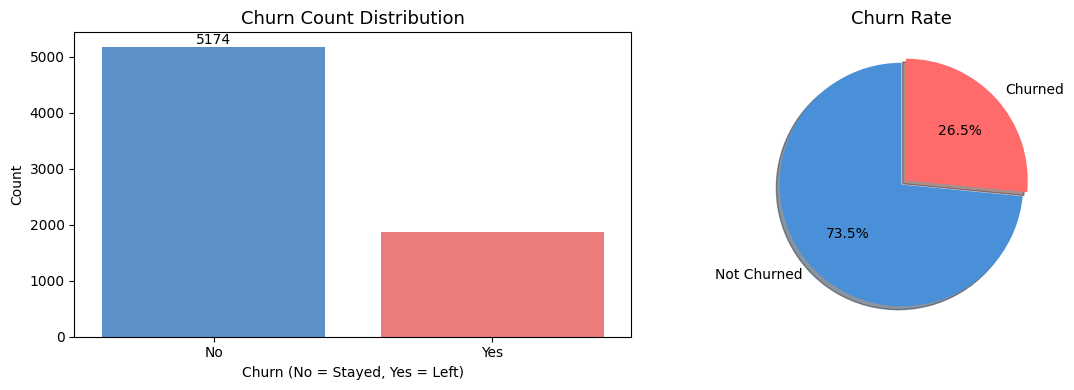

Note: Dataset is imbalanced — 73.5% not churned vs 26.5% churned.


In [8]:
# Target variable distribution - Univariate analysis
total = len(df)
churned = (df["Churn"] == "Yes").sum()
not_churned = total - churned

print(f"Total records    : {total:,}")
print(f"Churned (Yes)    : {churned:,}  ({churned/total*100:.1f}%)")
print(f"Not Churned (No) : {not_churned:,}  ({not_churned/total*100:.1f}%)")
print(f"\nClass imbalance ratio: 1:{not_churned/churned:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="Churn", data=df, palette=["#4A90D9", "#FF6B6B"], ax=axes[0])
axes[0].set_title("Churn Count Distribution", fontsize=13)
axes[0].set_xlabel("Churn (No = Stayed, Yes = Left)")
axes[0].set_ylabel("Count")
axes[0].bar_label(axes[0].containers[0])

axes[1].pie([not_churned, churned], labels=["Not Churned", "Churned"],
            autopct="%1.1f%%", colors=["#4A90D9", "#FF6B6B"], startangle=90,
            explode=[0, 0.05], shadow=True)
axes[1].set_title("Churn Rate", fontsize=13)

plt.tight_layout()
plt.show()
print("Note: Dataset is imbalanced — 73.5% not churned vs 26.5% churned.")

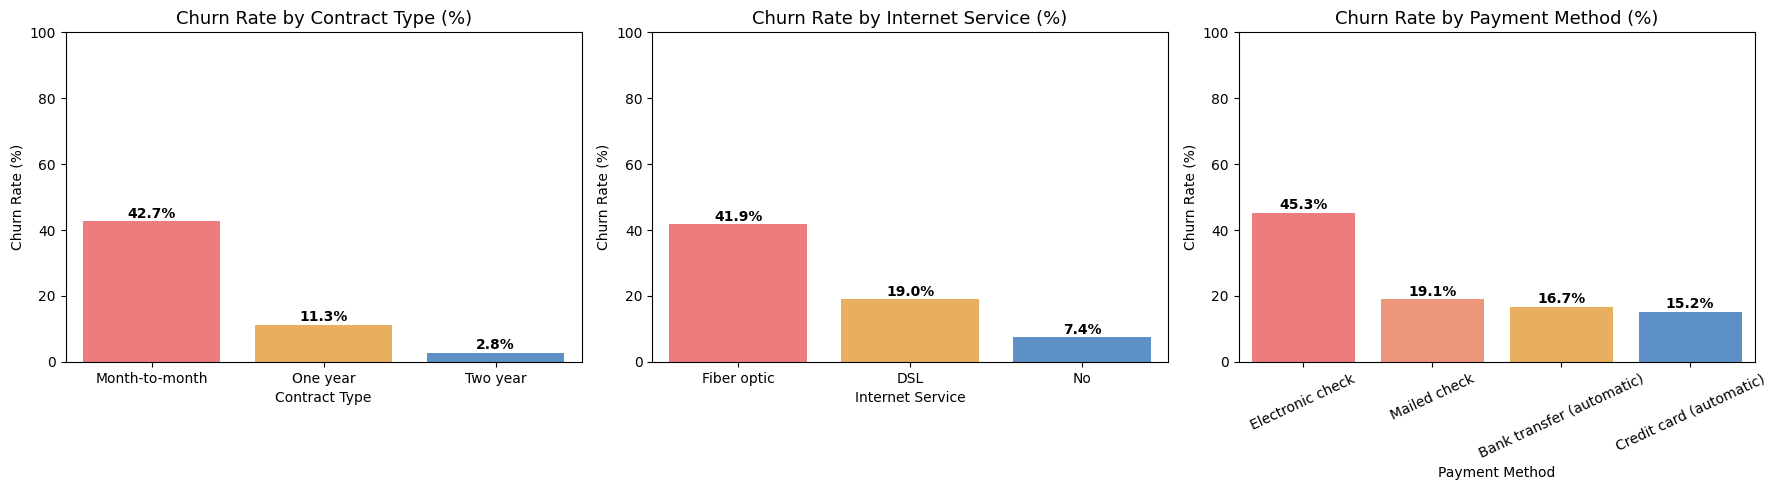

In [9]:
# Churn rate by key categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Churn by Contract Type
contract_churn = df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean()).sort_values(ascending=False) * 100
sns.barplot(x=contract_churn.index, y=contract_churn.values,
            palette=["#FF6B6B", "#FFB347", "#4A90D9"], ax=axes[0])
axes[0].set_title("Churn Rate by Contract Type (%)", fontsize=13)
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 100)
for i, v in enumerate(contract_churn.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")

# 2. Churn by Internet Service
internet_churn = df.groupby("InternetService")["Churn"].apply(lambda x: (x == "Yes").mean()).sort_values(ascending=False) * 100
sns.barplot(x=internet_churn.index, y=internet_churn.values,
            palette=["#FF6B6B", "#FFB347", "#4A90D9"], ax=axes[1])
axes[1].set_title("Churn Rate by Internet Service (%)", fontsize=13)
axes[1].set_xlabel("Internet Service")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_ylim(0, 100)
for i, v in enumerate(internet_churn.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")

# 3. Churn by Payment Method
payment_churn = df.groupby("PaymentMethod")["Churn"].apply(lambda x: (x == "Yes").mean()).sort_values(ascending=False) * 100
sns.barplot(x=payment_churn.index, y=payment_churn.values,
            palette=["#FF6B6B", "#FF8C69", "#FFB347", "#4A90D9"], ax=axes[2])
axes[2].set_title("Churn Rate by Payment Method (%)", fontsize=13)
axes[2].set_xlabel("Payment Method")
axes[2].set_ylabel("Churn Rate (%)")
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis='x', rotation=25)
for i, v in enumerate(payment_churn.values):
    axes[2].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

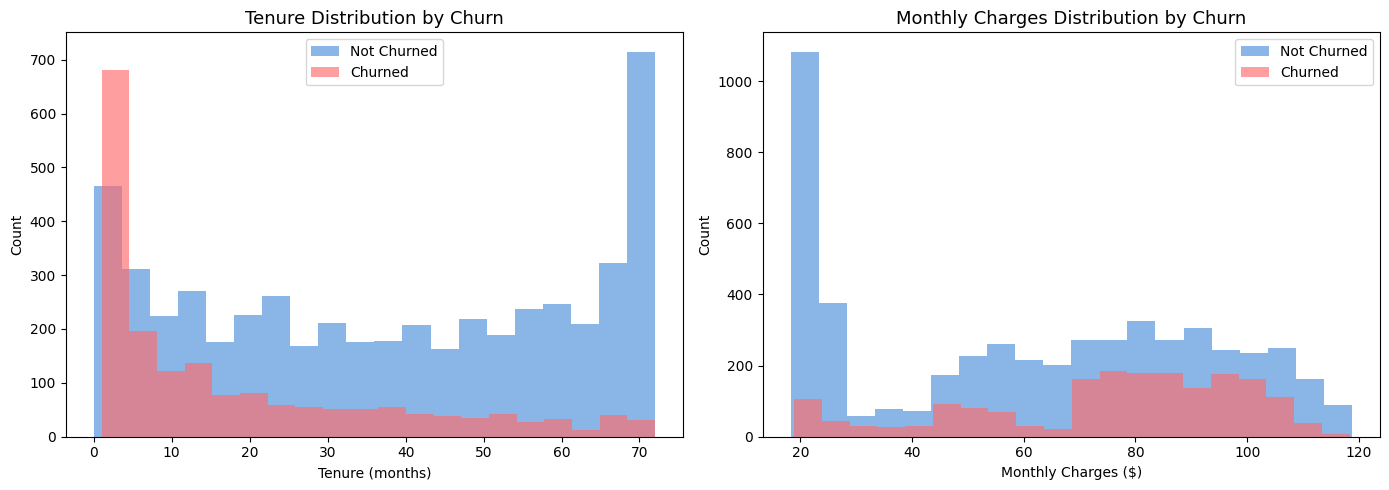

In [10]:
# Numerical feature distribution by Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df["Churn"] == "No"]["tenure"].plot(kind="hist", bins=20, alpha=0.65,
    label="Not Churned", ax=axes[0], color="#4A90D9")
df[df["Churn"] == "Yes"]["tenure"].plot(kind="hist", bins=20, alpha=0.65,
    label="Churned", ax=axes[0], color="#FF6B6B")
axes[0].set_title("Tenure Distribution by Churn", fontsize=13)
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Count")
axes[0].legend()

df[df["Churn"] == "No"]["MonthlyCharges"].plot(kind="hist", bins=20, alpha=0.65,
    label="Not Churned", ax=axes[1], color="#4A90D9")
df[df["Churn"] == "Yes"]["MonthlyCharges"].plot(kind="hist", bins=20, alpha=0.65,
    label="Churned", ax=axes[1], color="#FF6B6B")
axes[1].set_title("Monthly Charges Distribution by Churn", fontsize=13)
axes[1].set_xlabel("Monthly Charges ($)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 4. DATA PREPROCESSING & FEATURE SELECTION
# ============================================================

# Drop customerID — unique identifier, no predictive value
df_clean = df.drop(columns=["customerID"])

print(f"Columns after dropping customerID: {df_clean.shape[1]}")
print(df_clean.columns.tolist())

Columns after dropping customerID: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [12]:
# TotalCharges is stored as string due to 11 blank entries
# These are new customers with tenure = 0 who haven't been billed yet

print(f"TotalCharges dtype BEFORE: {df_clean['TotalCharges'].dtype}")

# Convert to numeric — blanks become NaN
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
print(f"Null values after conversion: {df_clean['TotalCharges'].isnull().sum()}")

# Impute NaN with 0 — these customers have tenure=0, so total charges = 0
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)
print(f"Null values after imputation: {df_clean['TotalCharges'].isnull().sum()}")
print(f"TotalCharges dtype AFTER: {df_clean['TotalCharges'].dtype}")

TotalCharges dtype BEFORE: object
Null values after conversion: 11
Null values after imputation: 0
TotalCharges dtype AFTER: float64


In [13]:
# Check and remove duplicates
dupes = df_clean.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f"Removed {dupes} duplicates")
    print(f"Shape after removal: {df_clean.shape}")

Duplicate rows: 22
Removed 22 duplicates
Shape after removal: (7021, 20)


In [14]:
# Statistical summary of cleaned data
df_clean.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7021.0,0.16,0.37,0.00,0.00,0.00,0.0,1.00
tenure,7021.0,32.47,24.53,0.00,9.00,29.00,55.0,72.00
MonthlyCharges,7021.0,64.85,30.07,18.25,35.75,70.40,89.9,118.75
TotalCharges,7021.0,2286.77,2266.86,0.00,403.35,1400.55,3801.7,8684.80


In [15]:
# ============================================================
# 5. ENCODING CATEGORICAL VARIABLES
# ============================================================

# LabelEncoder assigns integers to each category
# Fine for tree-based models; acceptable for Logistic Regression here

le = LabelEncoder()
cat_cols = ["gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
            "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
            "PaperlessBilling", "PaymentMethod", "Churn"]

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
MultipleLines: {'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
OnlineSecurity: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
OnlineBackup: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
DeviceProtection: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
TechSupport: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
StreamingTV: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
StreamingMovies: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Contract: {'Month-to-month': np.int64(0), 'One year': np.int64(1), 'Two 

In [16]:
# ============================================================
# 6. OUTLIER DETECTION
# ============================================================

from scipy.stats import zscore

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
z_scores = df_clean[num_cols].apply(zscore)
outlier_counts = (z_scores.abs() > 3).sum()

print("Outliers (|Z-score| > 3) per column:")
print(outlier_counts)
print(f"\nTotal outlier cells: {outlier_counts.sum()}")
print("Note: No significant outliers found. Data is clean for modelling.")

Outliers (|Z-score| > 3) per column:
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64

Total outlier cells: 0
Note: No significant outliers found. Data is clean for modelling.


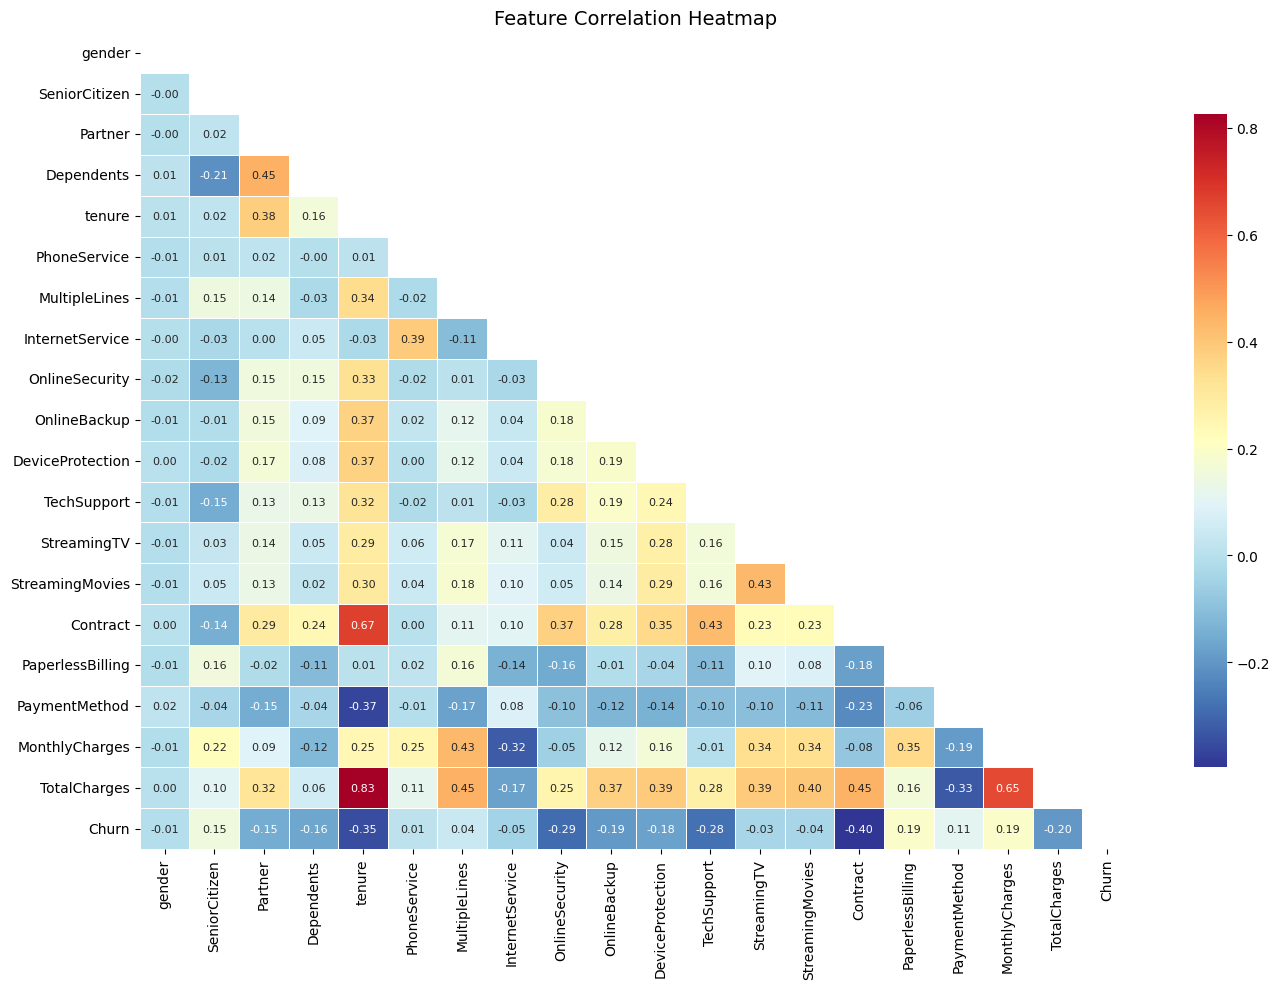

Features most correlated with Churn:
Contract           -0.397
tenure             -0.352
OnlineSecurity     -0.289
TechSupport        -0.282
TotalCharges       -0.197
MonthlyCharges      0.195
OnlineBackup       -0.194
PaperlessBilling    0.191
DeviceProtection   -0.177
Dependents         -0.163
SeniorCitizen       0.152
Partner            -0.149
PaymentMethod       0.106
InternetService    -0.047
MultipleLines       0.040
StreamingMovies    -0.036
StreamingTV        -0.035
PhoneService        0.011
gender             -0.009
Name: Churn, dtype: float64


In [17]:
# ============================================================
# 7. CORRELATION ANALYSIS
# ============================================================

plt.figure(figsize=(14, 10))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu_r",
            mask=mask, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

# Top features correlated with Churn
corr_target = corr["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
print("Features most correlated with Churn:")
print(corr_target.round(3))

In [18]:
# ============================================================
# 8. FEATURE ENGINEERING & TRAIN/TEST SPLIT
# ============================================================

X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nClass distribution:\n{y.value_counts()}")
print(f"\nChurn rate: {y.mean()*100:.1f}%")

Features (X): (7021, 19)
Target  (y): (7021,)

Class distribution:
Churn
0    5164
1    1857
Name: count, dtype: int64

Churn rate: 26.4%


In [19]:
# Stratified split — preserves churn ratio in both train and test sets
# 80% train, 20% test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test  churn rate: {y_test.mean()*100:.1f}%")

Train size: 5,616  |  Test size: 1,405
Train churn rate: 26.4%
Test  churn rate: 26.5%


In [20]:
# Scale features — required for Logistic Regression and KNN
# Tree-based models don't need scaling but it doesn't hurt them

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled with StandardScaler")

Features scaled with StandardScaler


In [21]:
# Reusable evaluation function for all models
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)

def evaluate_model(name, y_test, y_pred, y_prob=None):
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")
    if y_prob is not None:
        print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["Not Churned", "Churned"]))

In [22]:
# ============================================================
# 9. MODEL 1 — LOGISTIC REGRESSION
# ============================================================

# class_weight='balanced' adjusts for the 73.5/26.5 imbalance
# Uses SCALED data since Logistic Regression is magnitude-sensitive

log_model = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("Logistic Regression", y_test, log_pred, log_prob)

  Logistic Regression
  Accuracy  : 0.7431
  Precision : 0.5096
  Recall    : 0.7876
  F1 Score  : 0.6188
  ROC-AUC   : 0.8385

              precision    recall  f1-score   support

 Not Churned       0.90      0.73      0.81      1033
     Churned       0.51      0.79      0.62       372

    accuracy                           0.74      1405
   macro avg       0.71      0.76      0.71      1405
weighted avg       0.80      0.74      0.76      1405



In [23]:
# ============================================================
# 10. MODEL 2 — DECISION TREE
# ============================================================

# max_depth=5 prevents overfitting (limits tree complexity)
# Uses UNSCALED data — trees split on thresholds, not distances

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5, class_weight="balanced")
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

evaluate_model("Decision Tree", y_test, dt_pred, dt_prob)

  Decision Tree
  Accuracy  : 0.7601
  Precision : 0.5349
  Recall    : 0.7204
  F1 Score  : 0.6140
  ROC-AUC   : 0.8218

              precision    recall  f1-score   support

 Not Churned       0.88      0.77      0.83      1033
     Churned       0.53      0.72      0.61       372

    accuracy                           0.76      1405
   macro avg       0.71      0.75      0.72      1405
weighted avg       0.79      0.76      0.77      1405



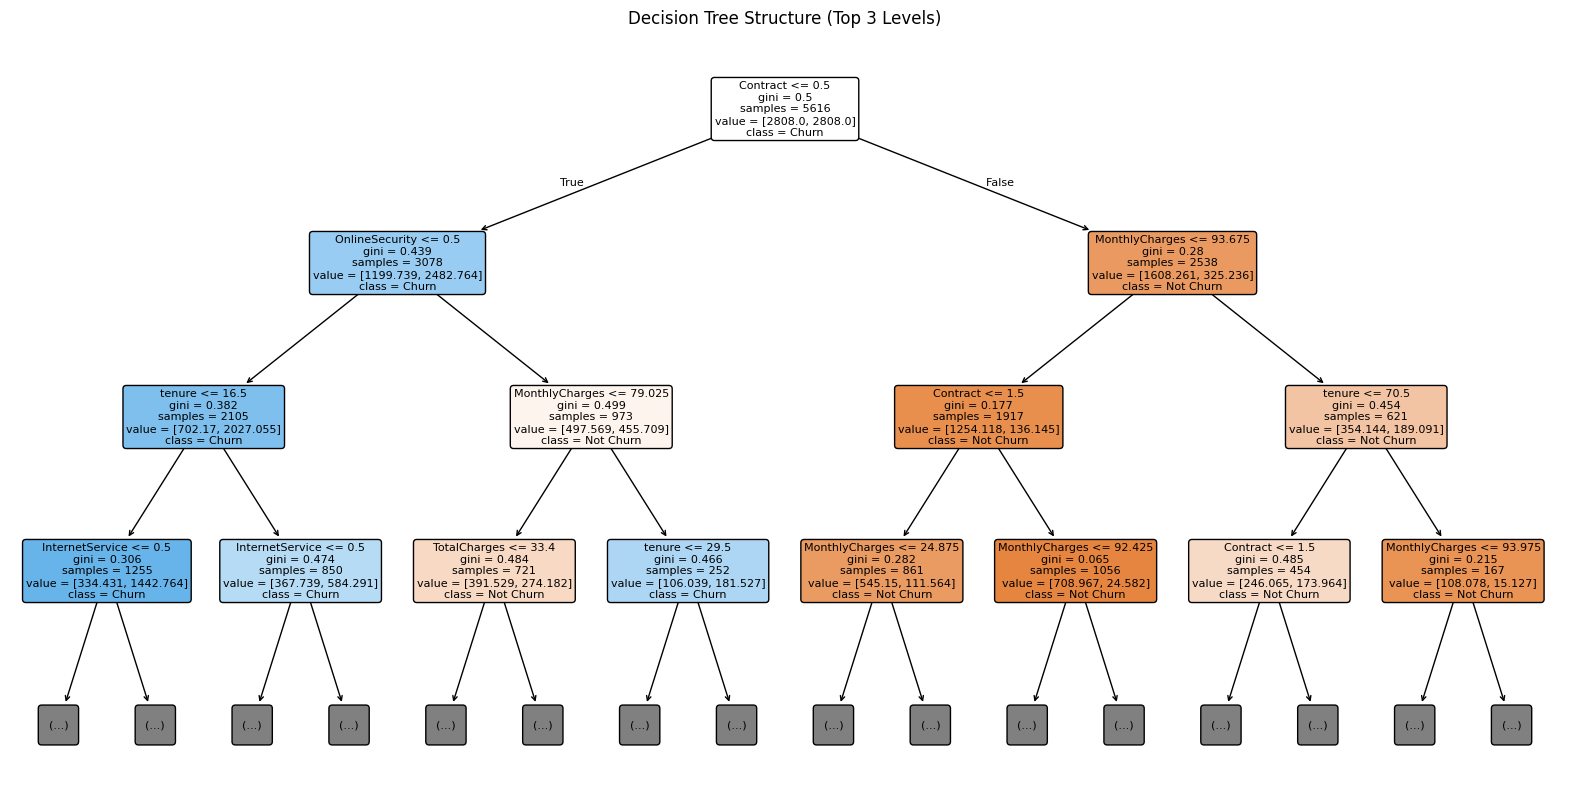

In [31]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=["Not Churn", "Churn"],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree Structure (Top 3 Levels)")
plt.show()

In [24]:
# ============================================================
# 11. MODEL 3 — RANDOM FOREST
# ============================================================

# n_estimators=100 — builds 100 decision trees and averages their votes
# max_depth=10 — controls individual tree complexity
# Uses UNSCALED data — ensemble of trees, same logic as Decision Tree

rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, class_weight="balanced")
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, rf_pred, rf_prob)

  Random Forest
  Accuracy  : 0.7772
  Precision : 0.5660
  Recall    : 0.6801
  F1 Score  : 0.6178
  ROC-AUC   : 0.8361

              precision    recall  f1-score   support

 Not Churned       0.88      0.81      0.84      1033
     Churned       0.57      0.68      0.62       372

    accuracy                           0.78      1405
   macro avg       0.72      0.75      0.73      1405
weighted avg       0.79      0.78      0.78      1405



In [25]:
# ============================================================
# 12. MODEL 4 — K-NEAREST NEIGHBORS (KNN)
# ============================================================

# n_neighbors=5 — classifies based on 5 closest data points
# Uses SCALED data — KNN is distance-based, needs uniform feature scales

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("KNN", y_test, knn_pred, knn_prob)

  KNN
  Accuracy  : 0.7559
  Precision : 0.5443
  Recall    : 0.4785
  F1 Score  : 0.5093
  ROC-AUC   : 0.7636

              precision    recall  f1-score   support

 Not Churned       0.82      0.86      0.84      1033
     Churned       0.54      0.48      0.51       372

    accuracy                           0.76      1405
   macro avg       0.68      0.67      0.67      1405
weighted avg       0.75      0.76      0.75      1405



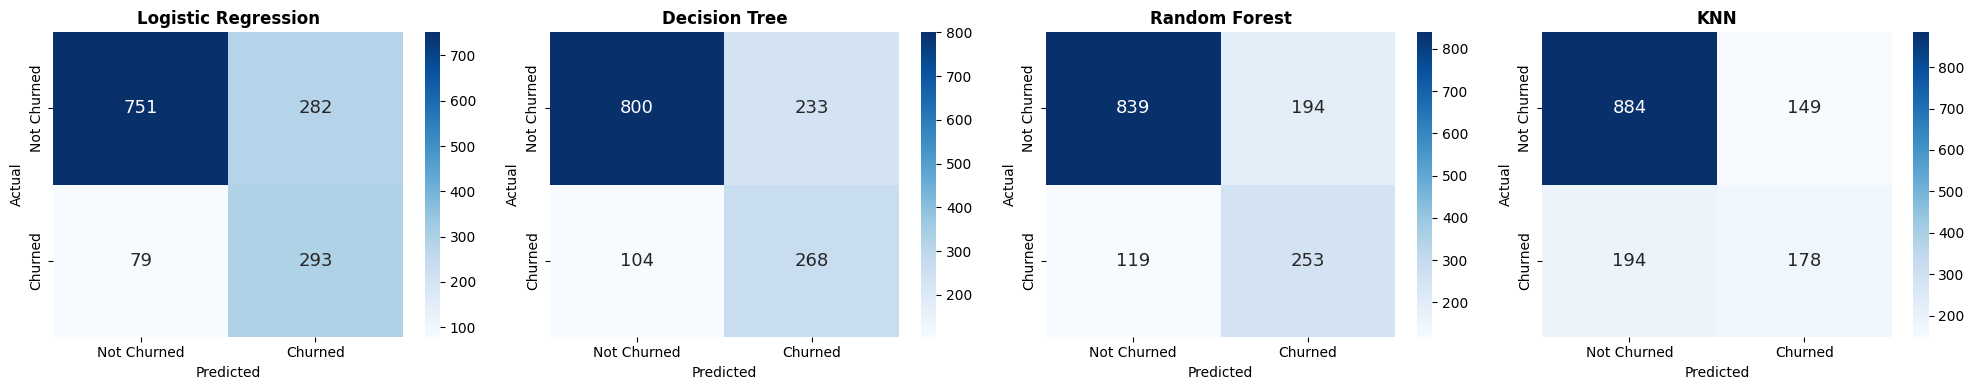

In [26]:
# ============================================================
# 13. MODEL EVALUATION — CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

models = {
    "Logistic Regression": log_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred
}

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Churned", "Churned"],
                yticklabels=["Not Churned", "Churned"],
                annot_kws={"size": 13})
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

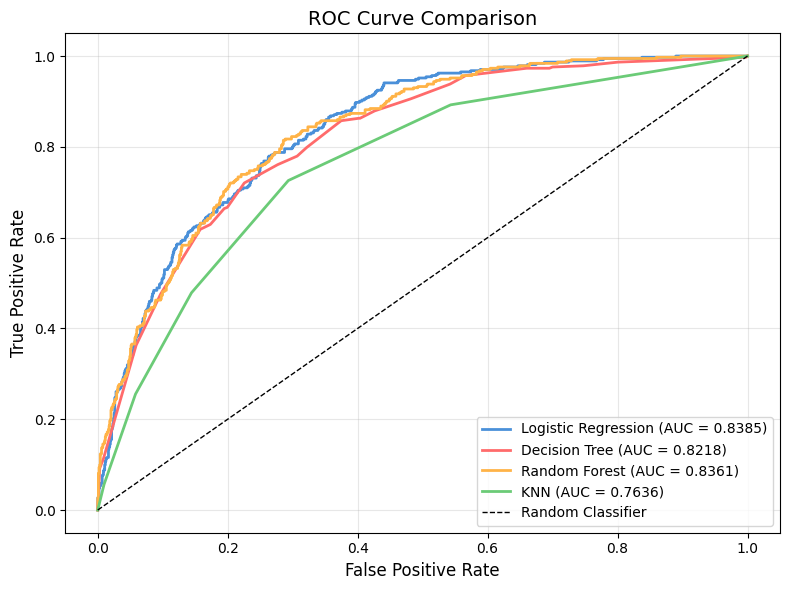

In [27]:
# ============================================================
# 14. MODEL EVALUATION — ROC CURVES
# ============================================================

from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

colors = ["#4A90D9", "#FF6B6B", "#FFB347", "#6BCB77"]
probs = {
    "Logistic Regression": log_prob,
    "Decision Tree": dt_prob,
    "Random Forest": rf_prob,
    "KNN": knn_prob
}

for (name, y_prob), color in zip(probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random Classifier")
ax.set_title("ROC Curve Comparison", fontsize=14)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# 15. COMPARISON LEADERBOARD
# ============================================================

results = []
all_models = {
    "Logistic Regression": (log_pred, log_prob),
    "Decision Tree": (dt_pred, dt_prob),
    "Random Forest": (rf_pred, rf_prob),
    "KNN": (knn_pred, knn_prob)
}

for name, (y_pred, y_prob) in all_models.items():
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4)
    })

leaderboard = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
leaderboard.index = leaderboard.index + 1
leaderboard.index.name = "Rank"

print("=" * 70)
print("          MODEL COMPARISON LEADERBOARD")
print("=" * 70)
print(leaderboard.to_string())
print("\nBest Model:", leaderboard.iloc[0]["Model"], "with ROC-AUC:", leaderboard.iloc[0]["ROC-AUC"])

          MODEL COMPARISON LEADERBOARD
                    Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Rank                                                                     
1     Logistic Regression    0.7431     0.5096  0.7876    0.6188   0.8385
2           Random Forest    0.7772     0.5660  0.6801    0.6178   0.8361
3           Decision Tree    0.7601     0.5349  0.7204    0.6140   0.8218
4                     KNN    0.7559     0.5443  0.4785    0.5093   0.7636

Best Model: Logistic Regression with ROC-AUC: 0.8385


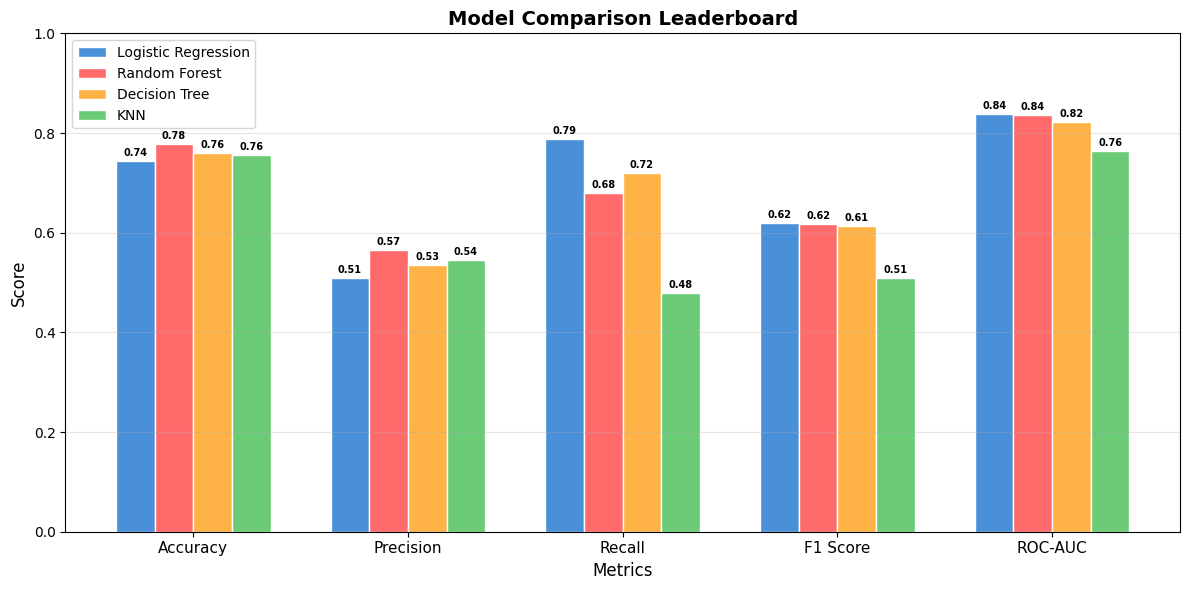

In [29]:
# Visual comparison of all models across metrics

fig, ax = plt.subplots(figsize=(12, 6))
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
x = np.arange(len(metrics))
width = 0.18
colors = ["#4A90D9", "#FF6B6B", "#FFB347", "#6BCB77"]

for i, (_, row) in enumerate(leaderboard.iterrows()):
    values = [row[m] for m in metrics]
    ax.bar(x + i * width, values, width, label=row["Model"], color=colors[i], edgecolor="white")

ax.set_xlabel("Metrics", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Comparison Leaderboard", fontsize=14, fontweight="bold")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

for i, (_, row) in enumerate(leaderboard.iterrows()):
    values = [row[m] for m in metrics]
    for j, v in enumerate(values):
        ax.text(x[j] + i * width, v + 0.01, f"{v:.2f}", ha="center", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# 16. DEMOCRATIZATION — DEPLOYING THE SOLUTION
# ============================================================

print("""
======================================================================
          HOW TO DEMOCRATIZE THIS SOLUTION
======================================================================

BUSINESS PROBLEM SOLVED:
Our best model (Logistic Regression, ROC-AUC = 0.8385) can predict
which telecom customers are likely to churn, enabling the marketing
team to launch targeted retention campaigns before customers leave.

HOW TO DEPLOY THIS IN THE REAL WORLD:

1. WEB APPLICATION (Streamlit / Flask)
   - Build a simple web dashboard where the marketing team can input
     customer details (tenure, contract type, monthly charges, etc.)
     and get an instant churn prediction with probability score.
   - No coding knowledge required for end users.

2. BATCH PREDICTION PIPELINE
   - Run the model monthly on the entire customer database.
   - Generate a ranked list of high-risk customers (churn probability > 0.5).
   - Automatically send this list to the CRM system for the retention team.

3. API DEPLOYMENT
   - Deploy the model as a REST API using Flask or FastAPI.
   - Other systems (CRM, billing, customer support) can call the API
     in real-time to check churn risk during customer interactions.

4. DASHBOARD INTEGRATION (Power BI / Tableau)
   - Export predictions and feature importance into a BI dashboard.
   - Marketing managers can filter by risk level, contract type,
     and region to design targeted campaigns.

BUSINESS IMPACT:
   - Reduce churn by 10-15% through early intervention.
   - Save customer acquisition costs (5-7x more expensive than retention).
   - Prioritize marketing budget on high-risk customers instead of
     blanket campaigns, improving ROI.

TOOLS & TECHNOLOGIES:
   - Model Serving  : Streamlit, Flask, FastAPI
   - Cloud Hosting  : AWS SageMaker, Google Cloud AI, Azure ML
   - Monitoring     : MLflow for model versioning and performance tracking
   - Retraining     : Schedule monthly retraining with fresh customer data
                      to keep the model accurate over time.
======================================================================
""")


          HOW TO DEMOCRATIZE THIS SOLUTION

BUSINESS PROBLEM SOLVED:
Our best model (Logistic Regression, ROC-AUC = 0.8385) can predict
which telecom customers are likely to churn, enabling the marketing
team to launch targeted retention campaigns before customers leave.

HOW TO DEPLOY THIS IN THE REAL WORLD:

1. WEB APPLICATION (Streamlit / Flask)
   - Build a simple web dashboard where the marketing team can input
     customer details (tenure, contract type, monthly charges, etc.)
     and get an instant churn prediction with probability score.
   - No coding knowledge required for end users.

2. BATCH PREDICTION PIPELINE
   - Run the model monthly on the entire customer database.
   - Generate a ranked list of high-risk customers (churn probability > 0.5).
   - Automatically send this list to the CRM system for the retention team.

3. API DEPLOYMENT
   - Deploy the model as a REST API using Flask or FastAPI.
   - Other systems (CRM, billing, customer support) can call the API
    